# IPL Score Predictor — Step 1: Train Model A & Model B
**Project 4: Game Score Predictor A/B Test**  
Part of Kranthi's MLOps 20-Hour Plan

---
### What this notebook does
1. Loads `ipl.csv` — ball-by-ball data (283k rows, 65 columns)
2. Aggregates to match-level (one row per first innings)
3. Engineers 9 features for Model A, 16 for Model B
4. Trains **Model A** — XGBoost v1.0 (production baseline)
5. Trains **Model B** — LightGBM v2.0 (challenger, extra cricket features)
6. Logs both to **MLflow** with artifacts going to **S3**
7. Registers and promotes in MLflow Model Registry

### Prerequisites
- `ipl.csv` in the same folder as this notebook
- AWS credentials configured: `aws configure`
- MLflow running with S3 artifact root:
```bash
mlflow server \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root s3://ipl-score-estimator-mlflow-artifacts/mlflow \
  --host 0.0.0.0 \
  --port 5000
```

### DevOps Bridge
| MLOps | Your world |
|---|---|
| MLflow experiment | Jenkins pipeline |
| MLflow Model Registry | Artifactory / ECR |
| **S3 artifact store** | S3 deployment bucket |
| Production stage | Prod environment |
| Staging stage | Staging environment |

**Why S3?** Artifacts stored in S3 work from your laptop, inside Docker, and on ECS — no file paths, no volume mounts, no machine-specific issues.

## 0. Install dependencies

In [5]:
pip install mlflow xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn boto3

Note: you may need to restart the kernel to use updated packages.


## 1. Configuration

In [33]:
# ── Update these if needed ─────────────────────────────────────────────────
MLFLOW_URI       = 'http://13.221.178.90:5000' # EC2 instance public IP for MLflow tracking server
S3_BUCKET        = 'ipl-score-estimator-mlflow-artifacts'
S3_ARTIFACT_ROOT = f's3://{S3_BUCKET}/mlflow'
EXPERIMENT_NAME  = 'ipl-score-predictor-v2'
MODEL_NAME       = 'ipl-score-predictor'
DATA_FILE        = 'ipl.csv'

print(f'MLflow URI:       {MLFLOW_URI}')
print(f'S3 artifact root: {S3_ARTIFACT_ROOT}')
print(f'Experiment:       {EXPERIMENT_NAME}')

MLflow URI:       http://13.221.178.90:5000
S3 artifact root: s3://ipl-score-estimator-mlflow-artifacts/mlflow
Experiment:       ipl-score-predictor-v2


## 2. Verify MLflow is pointing to S3
**Run this before anything else.** If it shows a local path, stop and restart MLflow with the S3 artifact root shown above.

In [34]:
import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

client = MlflowClient()
exp    = client.get_experiment_by_name(EXPERIMENT_NAME)

print(f'Artifact location: {exp.artifact_location}')

if exp.artifact_location.startswith('s3://'):
    print('\n✅ S3 confirmed — artifacts will be stored in S3')
    print('   Docker and ECS will load models directly from S3')
else:
    print('\n⚠️  NOT S3 — stop and restart MLflow:')
    print(f'   mlflow server --backend-store-uri sqlite:///mlflow.db --default-artifact-root {S3_ARTIFACT_ROOT} --host 0.0.0.0 --port 5000')
    raise SystemExit('Fix MLflow artifact root before continuing')

2026/05/29 11:58:29 INFO mlflow.tracking.fluent: Experiment with name 'ipl-score-predictor-v2' does not exist. Creating a new experiment.


Artifact location: s3://ipl-score-estimator-mlflow-artifacts/mlflow/1

✅ S3 confirmed — artifacts will be stored in S3
   Docker and ECS will load models directly from S3


## 3. Load the dataset

In [14]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

raw = pd.read_csv(DATA_FILE, low_memory=False)

print(f'Raw shape:     {raw.shape}')
print(f'Total matches: {raw["match_id"].nunique()}')
print(f'Seasons:       {sorted(raw["season"].dropna().unique())}')
print(f'Teams:         {sorted(raw["batting_team"].dropna().unique())}')

Raw shape:     (283678, 65)
Total matches: 1193
Seasons:       ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025', '2026']
Teams:         ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


## 4. Aggregate — ball-by-ball → one row per match

In [15]:
# Keep T20 first innings only
raw = raw[raw['match_type'] == 'T20'].copy()
raw = raw[raw['innings'] == 1].copy()
print(f'First innings deliveries: {len(raw)}')
print(f'Matches:                  {raw["match_id"].nunique()}')

First innings deliveries: 146997
Matches:                  1193


In [16]:
match_scores = (
    raw.groupby('match_id')
    .agg(
        total_score   = ('runs_total',   'sum'),
        total_wickets = ('wicket_kind',  lambda x: x.notna().sum()),
        total_balls   = ('valid_ball',   'sum'),
        batting_team  = ('batting_team', 'first'),
        bowling_team  = ('bowling_team', 'first'),
        venue         = ('venue',        'first'),
        city          = ('city',         'first'),
        toss_winner   = ('toss_winner',  'first'),
        toss_decision = ('toss_decision','first'),
        year          = ('year',         'first'),
        season        = ('season',       'first'),
        month         = ('month',        'first'),
    )
    .reset_index()
)

# Remove outliers
df = match_scores[
    (match_scores['total_score'] >= 80)  &
    (match_scores['total_score'] <= 280) &
    (match_scores['total_balls']  >= 60)
].copy()
df = df.sort_values(['year', 'match_id']).reset_index(drop=True)

print(f'Match-level dataset: {df.shape}')
print(f'Score range:         {df["total_score"].min()} – {df["total_score"].max()}')
print(f'Average score:       {df["total_score"].mean():.1f}')

Match-level dataset: (1181, 13)
Score range:         80 – 278
Average score:       168.0


## 5. EDA

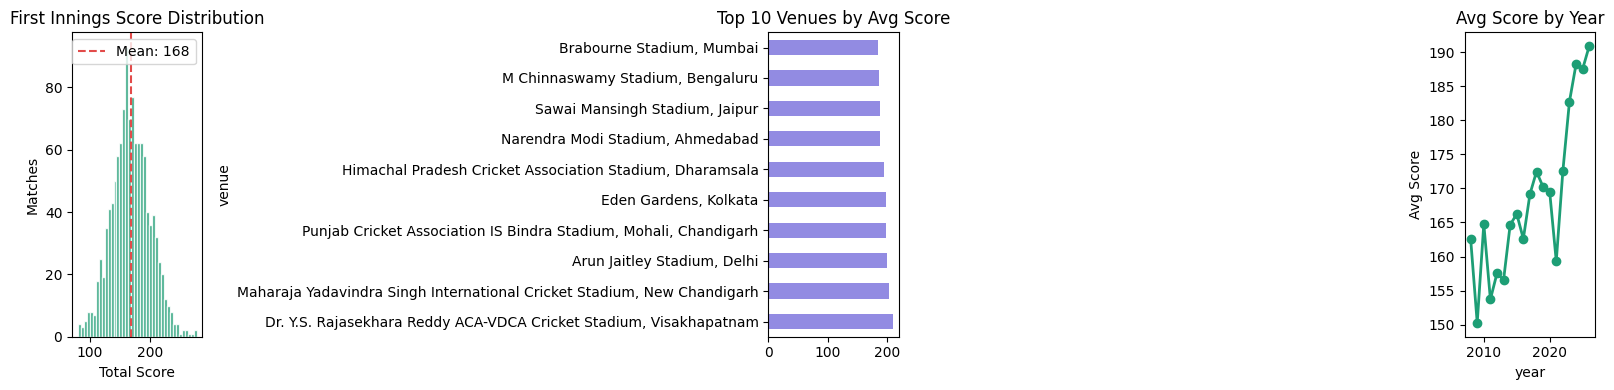

Saved: ipl_eda.png


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['total_score'], bins=40, color='#1D9E75', alpha=0.85, edgecolor='white')
axes[0].axvline(df['total_score'].mean(), color='#E24B4A', linestyle='--',
                label=f"Mean: {df['total_score'].mean():.0f}")
axes[0].set_title('First Innings Score Distribution')
axes[0].set_xlabel('Total Score'); axes[0].set_ylabel('Matches'); axes[0].legend()

df.groupby('venue')['total_score'].mean().nlargest(10).plot(
    kind='barh', ax=axes[1], color='#7F77DD', alpha=0.85)
axes[1].set_title('Top 10 Venues by Avg Score')

df.groupby('year')['total_score'].mean().plot(
    kind='line', ax=axes[2], color='#1D9E75', marker='o', linewidth=2)
axes[2].set_title('Avg Score by Year')
axes[2].set_ylabel('Avg Score')

plt.tight_layout()
plt.savefig('ipl_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: ipl_eda.png')

## 6. Feature Engineering

| Feature | Model A | Model B | Why it matters |
|---|:---:|:---:|---|
| `venue_avg_score` | ✓ | ✓ | Wankhede vs Chepauk play very differently |
| `batting_team_avg` | ✓ | ✓ | MI historically scores more than SRH |
| `batting_team_rolling` | ✓ | ✓ | Rolling 10-match avg |
| `toss_bat_first` | ✓ | ✓ | Toss decision changes approach |
| `year` | ✓ | ✓ | Scores rising each season |
| `month` | ✓ | ✓ | April vs May conditions differ |
| `batting_team_enc` | ✓ | ✓ | Encoded team identity |
| `bowling_team_enc` | ✓ | ✓ | Encoded bowling team |
| `venue_enc` | ✓ | ✓ | Encoded venue |
| `dew_factor` | ✗ | ✓ | Evening matches = dew = bowling harder |
| `batting_recent_form` | ✗ | ✓ | Last 5 match avg |
| `form_ratio` | ✗ | ✓ | Recent vs long-term form |
| `h2h_avg` | ✗ | ✓ | Head-to-head historical avg |
| `bowling_team_avg_conceded` | ✗ | ✓ | Bowling team strength |
| `is_home_ground` | ✗ | ✓ | Home advantage |
| `modern_era` | ✗ | ✓ | Post-2020 batting evolution |

In [18]:
from sklearn.preprocessing import LabelEncoder

# ── Shared features ────────────────────────────────────────────────────────
venue_avg_map = df.groupby('venue')['total_score'].mean()
df['venue_avg_score'] = df['venue'].map(venue_avg_map)

team_avg_map = df.groupby('batting_team')['total_score'].mean()
df['batting_team_avg'] = df['batting_team'].map(team_avg_map)

df['batting_team_rolling'] = (
    df.groupby('batting_team')['total_score']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
    .fillna(df['batting_team_avg'])
)

df['toss_bat_first'] = (
    (df['toss_winner'] == df['batting_team']) & (df['toss_decision'] == 'bat')
).astype(int)

le_team  = LabelEncoder()
le_venue = LabelEncoder()
le_team.fit(pd.concat([df['batting_team'], df['bowling_team']]).unique())

df['batting_team_enc'] = le_team.transform(df['batting_team'])
df['bowling_team_enc'] = le_team.transform(df['bowling_team'])
df['venue_enc']        = le_venue.fit_transform(df['venue'].fillna('Unknown'))

print('Shared features (Model A + B) done ✓')

Shared features (Model A + B) done ✓


In [19]:
# ── Model B extra features ─────────────────────────────────────────────────
dew_venues = ['Eden Gardens', 'Wankhede', 'Rajiv Gandhi', 'Arun Jaitley',
              'Chidambaram', 'Ekana', 'Narendra Modi']
df['dew_factor'] = df['venue'].str.contains('|'.join(dew_venues), case=False, na=False).astype(int)

df['batting_recent_form'] = (
    df.groupby('batting_team')['total_score']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=2).mean())
    .fillna(df['batting_team_avg'])
)
df['form_ratio'] = (df['batting_recent_form'] / df['batting_team_avg'].replace(0, 1)).clip(0.7, 1.3)

df['match_pair'] = df.apply(lambda r: '_'.join(sorted([r['batting_team'], r['bowling_team']])), axis=1)
df['h2h_avg']    = df['match_pair'].map(df.groupby('match_pair')['total_score'].mean()).fillna(df['batting_team_avg'])

df['bowling_team_avg_conceded'] = df['bowling_team'].map(df.groupby('bowling_team')['total_score'].mean())

home_city_map = {
    'Mumbai Indians': 'mumbai', 'Chennai Super Kings': 'chennai',
    'Royal Challengers Bangalore': 'bangalore', 'Royal Challengers Bengaluru': 'bengaluru',
    'Kolkata Knight Riders': 'kolkata', 'Delhi Capitals': 'delhi',
    'Delhi Daredevils': 'delhi', 'Sunrisers Hyderabad': 'hyderabad',
    'Rajasthan Royals': 'jaipur', 'Punjab Kings': 'mohali',
    'Kings XI Punjab': 'mohali', 'Gujarat Titans': 'ahmedabad',
    'Lucknow Super Giants': 'lucknow', 'Deccan Chargers': 'hyderabad',
    'Pune Warriors': 'pune', 'Rising Pune Supergiant': 'pune',
    'Rising Pune Supergiants': 'pune', 'Gujarat Lions': 'rajkot',
    'Kochi Tuskers Kerala': 'kochi',
}
df['is_home_ground'] = (
    df['city'].str.lower().str.strip() == df['batting_team'].map(home_city_map)
).astype(int)
df['modern_era'] = (df['year'] >= 2020).astype(int)

print('Model B extra features done ✓')
print(f'Dew factor:  {df["dew_factor"].sum()} of {len(df)} matches')
print(f'Home ground: {df["is_home_ground"].sum()} of {len(df)} matches')
print(f'Modern era:  {df["modern_era"].sum()} of {len(df)} matches')

Model B extra features done ✓
Dew factor:  503 of 1181 matches
Home ground: 374 of 1181 matches
Modern era:  433 of 1181 matches


## 7. Train / Test split — temporal (no data leakage)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FEATURES_A = [
    'venue_avg_score', 'batting_team_avg', 'batting_team_rolling',
    'toss_bat_first', 'year', 'month',
    'batting_team_enc', 'bowling_team_enc', 'venue_enc',
]
FEATURES_B = FEATURES_A + [
    'dew_factor', 'batting_recent_form', 'form_ratio', 'h2h_avg',
    'bowling_team_avg_conceded', 'is_home_ground', 'modern_era',
]
TARGET = 'total_score'

test_years = sorted(df['year'].unique())[-2:]
train_df   = df[~df['year'].isin(test_years)].copy()
test_df    = df[ df['year'].isin(test_years)].copy()

X_train_A = train_df[FEATURES_A]; X_test_A = test_df[FEATURES_A]
X_train_B = train_df[FEATURES_B]; X_test_B = test_df[FEATURES_B]
y_train   = train_df[TARGET];     y_test   = test_df[TARGET]

print(f'Train: {len(train_df)} matches | Years: {train_df["year"].min()}–{train_df["year"].max()}')
print(f'Test:  {len(test_df)}  matches | Years: {test_df["year"].min()}–{test_df["year"].max()}')
print(f'Model A features: {len(FEATURES_A)}')
print(f'Model B features: {len(FEATURES_B)}')

Train: 1085 matches | Years: 2008–2024
Test:  96  matches | Years: 2025–2026
Model A features: 9
Model B features: 16


## 8. Train Model A — XGBoost (Production baseline)
Artifacts → S3

In [21]:
import xgboost as xgb

params_A = {
    'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1,
}

with mlflow.start_run(run_name='model-a-xgboost') as run_a:
    mlflow.log_params(params_A)
    mlflow.log_param('model_version', 'v1.0')
    mlflow.log_param('algorithm',     'XGBoost')
    mlflow.log_param('feature_count', len(FEATURES_A))
    mlflow.log_param('features',      str(FEATURES_A))
    mlflow.log_param('train_years',   f'{train_df["year"].min()}–{train_df["year"].max()}')
    mlflow.log_param('test_years',    str(test_years))

    model_a = xgb.XGBRegressor(**params_A)
    model_a.fit(X_train_A, y_train, eval_set=[(X_test_A, y_test)], verbose=100)

    preds_a = model_a.predict(X_test_A)
    mae_a   = mean_absolute_error(y_test, preds_a)
    rmse_a  = np.sqrt(mean_squared_error(y_test, preds_a))
    r2_a    = r2_score(y_test, preds_a)
    acc_a   = float(np.mean(np.abs(preds_a - y_test) <= 12) * 100)

    mlflow.log_metric('mae',                     round(mae_a, 2))
    mlflow.log_metric('rmse',                    round(rmse_a, 2))
    mlflow.log_metric('r2',                      round(r2_a, 4))
    mlflow.log_metric('accuracy_within_12_runs', round(acc_a, 2))
    mlflow.log_artifact('ipl_eda.png')

    mlflow.xgboost.log_model(model_a, artifact_path='model', registered_model_name=MODEL_NAME)
    run_a_id = run_a.info.run_id
    print(f'Artifact URI: {run_a.info.artifact_uri}')

print(f'\nMODEL A — XGBoost')
print(f'  MAE      : {mae_a:.1f} runs')
print(f'  RMSE     : {rmse_a:.1f} runs')
print(f'  R²       : {r2_a:.3f}')
print(f'  Accuracy : {acc_a:.1f}%  (within ±12 runs)')

[0]	validation_0-rmse:41.35877
[100]	validation_0-rmse:37.49212
[200]	validation_0-rmse:39.11578
[299]	validation_0-rmse:40.21652


2026/05/28 12:42:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'ipl-score-predictor' already exists. Creating a new version of this model...
2026/05/28 12:43:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: ipl-score-predictor, version 12
Created version '12' of model 'ipl-score-predictor'.


Artifact URI: s3://ipl-score-estimator-mlflow-artifacts/mlflow/2/566d8cf674624746ab9539053c951a09/artifacts
🏃 View run model-a-xgboost at: http://localhost:5000/#/experiments/2/runs/566d8cf674624746ab9539053c951a09
🧪 View experiment at: http://localhost:5000/#/experiments/2

MODEL A — XGBoost
  MAE      : 32.9 runs
  RMSE     : 40.2 runs
  R²       : -0.278
  Accuracy : 26.0%  (within ±12 runs)


## 9. Train Model B — LightGBM (Challenger)
Artifacts → S3

In [22]:
import lightgbm as lgb

params_B = {
    'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.04,
    'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'random_state': 42, 'n_jobs': -1, 'verbose': -1,
}

with mlflow.start_run(run_name='model-b-lightgbm') as run_b:
    mlflow.log_params(params_B)
    mlflow.log_param('model_version', 'v2.0')
    mlflow.log_param('algorithm',     'LightGBM')
    mlflow.log_param('feature_count', len(FEATURES_B))
    mlflow.log_param('features',      str(FEATURES_B))
    mlflow.log_param('extra_vs_A',    'dew_factor, batting_recent_form, form_ratio, h2h_avg, bowling_team_avg_conceded, is_home_ground, modern_era')
    mlflow.log_param('train_years',   f'{train_df["year"].min()}–{train_df["year"].max()}')
    mlflow.log_param('test_years',    str(test_years))

    model_b = lgb.LGBMRegressor(**params_B)
    model_b.fit(X_train_B, y_train, eval_set=[(X_test_B, y_test)],
                callbacks=[lgb.log_evaluation(100)])

    preds_b = model_b.predict(X_test_B)
    mae_b   = mean_absolute_error(y_test, preds_b)
    rmse_b  = np.sqrt(mean_squared_error(y_test, preds_b))
    r2_b    = r2_score(y_test, preds_b)
    acc_b   = float(np.mean(np.abs(preds_b - y_test) <= 12) * 100)

    mlflow.log_metric('mae',                     round(mae_b, 2))
    mlflow.log_metric('rmse',                    round(rmse_b, 2))
    mlflow.log_metric('r2',                      round(r2_b, 4))
    mlflow.log_metric('accuracy_within_12_runs', round(acc_b, 2))

    mlflow.lightgbm.log_model(model_b, artifact_path='model', registered_model_name=MODEL_NAME)
    run_b_id = run_b.info.run_id
    print(f'Artifact URI: {run_b.info.artifact_uri}')

print(f'\nMODEL B — LightGBM')
print(f'  MAE      : {mae_b:.1f} runs')
print(f'  RMSE     : {rmse_b:.1f} runs')
print(f'  R²       : {r2_b:.3f}')
print(f'  Accuracy : {acc_b:.1f}%  (within ±12 runs)')

[100]	valid_0's l2: 1240.38
[200]	valid_0's l2: 1352.14
[300]	valid_0's l2: 1424.5
[400]	valid_0's l2: 1501.56


2026/05/28 12:44:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/28 12:44:01 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'ipl-score-predictor' already exists. Creating a new version of this model...
2026/05/28 12:44:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: ipl-score-predictor, version 13
Created version '13' of model 'ipl-score-predictor'.


Artifact URI: s3://ipl-score-estimator-mlflow-artifacts/mlflow/2/5066a747bf024c09bc6bb1848d3dddbb/artifacts
🏃 View run model-b-lightgbm at: http://localhost:5000/#/experiments/2/runs/5066a747bf024c09bc6bb1848d3dddbb
🧪 View experiment at: http://localhost:5000/#/experiments/2

MODEL B — LightGBM
  MAE      : 31.3 runs
  RMSE     : 38.7 runs
  R²       : -0.187
  Accuracy : 24.0%  (within ±12 runs)


## 10. Compare both models

In [23]:
summary = pd.DataFrame({
    'Metric': ['MAE (runs)', 'RMSE (runs)', 'R²', 'Accuracy ±12 runs', 'Features'],
    'Model A — XGBoost v1.0':  [f'{mae_a:.1f}', f'{rmse_a:.1f}', f'{r2_a:.3f}', f'{acc_a:.1f}%', len(FEATURES_A)],
    'Model B — LightGBM v2.0': [f'{mae_b:.1f}', f'{rmse_b:.1f}', f'{r2_b:.3f}', f'{acc_b:.1f}%', len(FEATURES_B)],
})
print(summary.to_string(index=False))
print(f'\n→ Lower MAE: {"Model B" if mae_b < mae_a else "Model A"}')
print(f'→ MAE difference: {abs(mae_a - mae_b):.1f} runs')

           Metric Model A — XGBoost v1.0 Model B — LightGBM v2.0
       MAE (runs)                   32.9                    31.3
      RMSE (runs)                   40.2                    38.7
               R²                 -0.278                  -0.187
Accuracy ±12 runs                  26.0%                   24.0%
         Features                      9                      16

→ Lower MAE: Model B
→ MAE difference: 1.5 runs


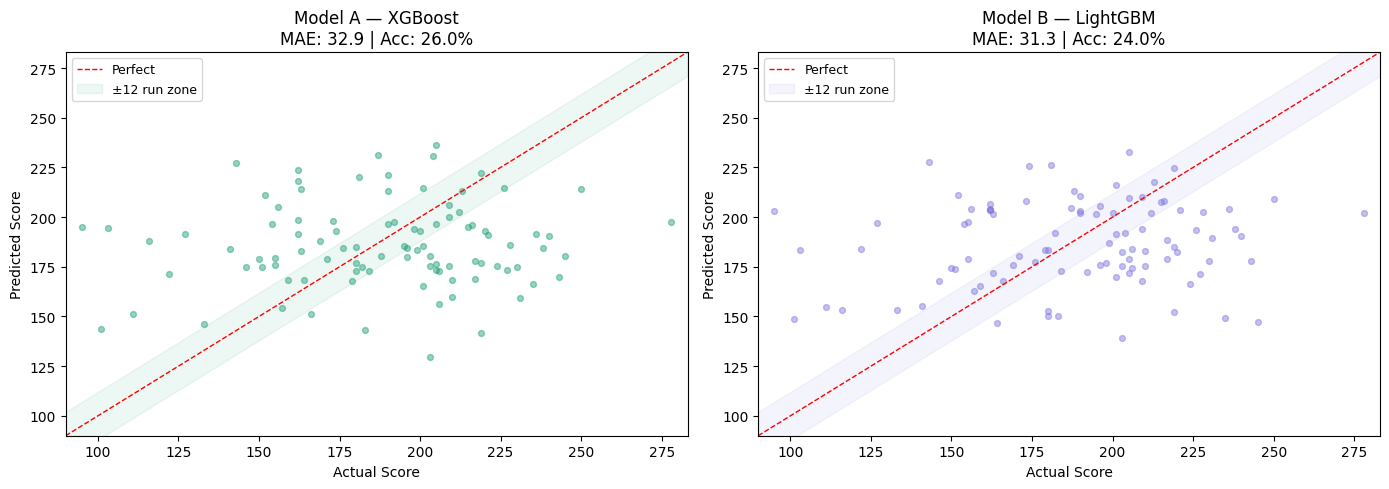

In [24]:
# Prediction scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, title, color in [
    (axes[0], preds_a, f'Model A — XGBoost\nMAE: {mae_a:.1f} | Acc: {acc_a:.1f}%', '#1D9E75'),
    (axes[1], preds_b, f'Model B — LightGBM\nMAE: {mae_b:.1f} | Acc: {acc_b:.1f}%', '#7F77DD'),
]:
    lo = min(float(y_test.min()), float(preds.min())) - 5
    hi = max(float(y_test.max()), float(preds.max())) + 5
    ax.scatter(y_test, preds, alpha=0.45, color=color, s=18)
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1, label='Perfect')
    ax.fill_between([lo, hi], [lo-12, hi-12], [lo+12, hi+12], alpha=0.08, color=color, label='±12 run zone')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual Score'); ax.set_ylabel('Predicted Score')
    ax.set_title(title); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

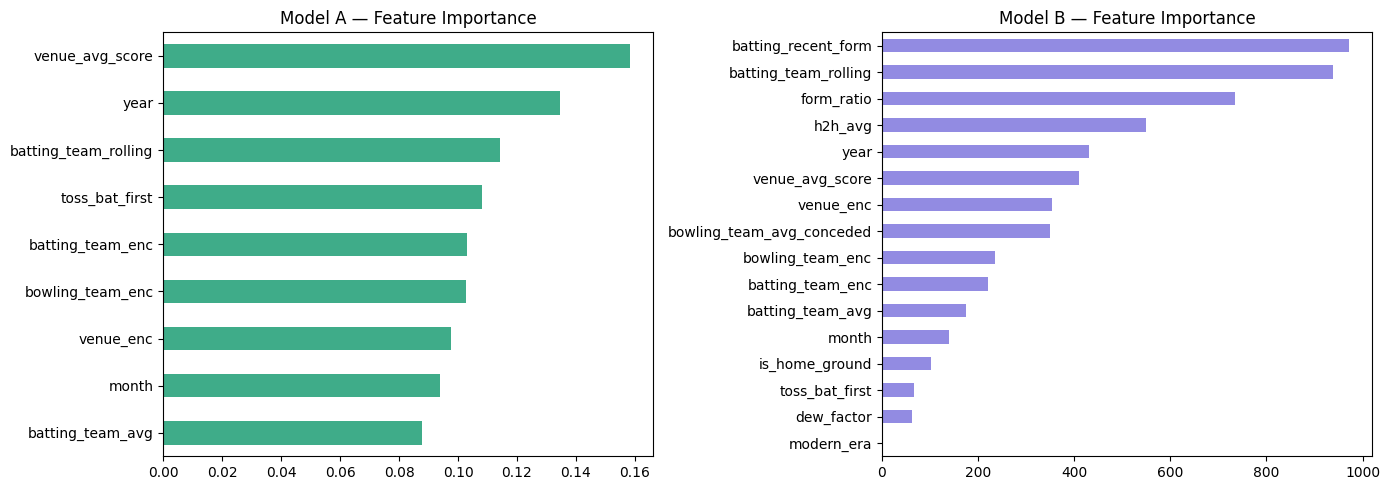

🏃 View run model-a-xgboost at: http://localhost:5000/#/experiments/2/runs/566d8cf674624746ab9539053c951a09
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run model-b-lightgbm at: http://localhost:5000/#/experiments/2/runs/5066a747bf024c09bc6bb1848d3dddbb
🧪 View experiment at: http://localhost:5000/#/experiments/2
Charts logged to MLflow ✓


In [25]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.Series(model_a.feature_importances_, index=FEATURES_A).sort_values()\
  .plot(kind='barh', ax=axes[0], color='#1D9E75', alpha=0.85)
axes[0].set_title('Model A — Feature Importance')
pd.Series(model_b.feature_importances_, index=FEATURES_B).sort_values()\
  .plot(kind='barh', ax=axes[1], color='#7F77DD', alpha=0.85)
axes[1].set_title('Model B — Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# Log charts to MLflow (stored in S3)
for run_id in [run_a_id, run_b_id]:
    with mlflow.start_run(run_id=run_id):
        mlflow.log_artifact('model_comparison.png')
        mlflow.log_artifact('feature_importance.png')
print('Charts logged to MLflow ✓')

## 11. Verify S3 artifacts + Promote in Registry

In [26]:
# Verify artifact URIs are S3 paths
run_a_info = client.get_run(run_a_id)
run_b_info = client.get_run(run_b_id)

print(f'Model A artifact URI: {run_a_info.info.artifact_uri}')
print(f'Model B artifact URI: {run_b_info.info.artifact_uri}')

assert run_a_info.info.artifact_uri.startswith('s3://'), \
    'Model A NOT in S3 — check MLflow server --default-artifact-root'
assert run_b_info.info.artifact_uri.startswith('s3://'), \
    'Model B NOT in S3 — check MLflow server --default-artifact-root'

print('\n✅ Both artifacts confirmed in S3')

Model A artifact URI: s3://ipl-score-estimator-mlflow-artifacts/mlflow/2/566d8cf674624746ab9539053c951a09/artifacts
Model B artifact URI: s3://ipl-score-estimator-mlflow-artifacts/mlflow/2/5066a747bf024c09bc6bb1848d3dddbb/artifacts

✅ Both artifacts confirmed in S3


In [37]:
import mlflow
import mlflow.xgboost
import mlflow.lightgbm
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("http://13.221.178.90:5000")
mlflow.set_experiment("ipl-score-predictor-v2")
client = MlflowClient()

# Find the two latest runs from this experiment
exp    = client.get_experiment_by_name("ipl-score-predictor-v2")
runs   = client.search_runs(
    experiment_ids=[exp.experiment_id],
    order_by=["start_time DESC"],
    max_results=2
)

for run in runs:
    print(f"Run: {run.info.run_id} | {run.data.params.get('algorithm')} | {run.info.artifact_uri}")

In [28]:
from mlflow.tracking import MlflowClient
client = MlflowClient()

versions = client.search_model_versions("name='ipl-score-predictor'")
for v in sorted(versions, key=lambda v: int(v.version)):
    print(f"v{v.version} | stage={v.current_stage} | uri={v.source}")

v1 | stage=Archived | uri=models:/m-4a0b900d76b14137aa432a8fde492861
v2 | stage=Archived | uri=models:/m-20a72f0147394f2db8716e9b98454cc0
v3 | stage=None | uri=models:/m-759b86777ae94bfb90071c421498242b
v4 | stage=None | uri=models:/m-4e6e0bb3aae44d35942cacdbccd82c4a
v5 | stage=Archived | uri=models:/m-caee1fb30a104a8993fefd78457e92ab
v6 | stage=Archived | uri=models:/m-a0b1bd87bbda48bd9c2e3b473c6ddba2
v7 | stage=Archived | uri=models:/m-9dc2e40bfe7647a584696058abead820
v8 | stage=None | uri=models:/m-0d0a299b4e2642cc95a80fc08ac60caf
v9 | stage=None | uri=models:/m-e27f05bec8154f74a6847959f6e234d0
v10 | stage=None | uri=models:/m-169d39deb1984bc3a3b6bde58b1e5faf
v11 | stage=None | uri=models:/m-54e2937764ef4ea886cdbe5cddb217f2
v12 | stage=Production | uri=models:/m-6b70dc7c760845a7a5f81a9f62d75e38
v13 | stage=Staging | uri=models:/m-2796242bb0ef4035b8dc8c53a8386013


In [29]:
from mlflow.tracking import MlflowClient
client = MlflowClient()

for v in ['12', '13']:
    mv = client.get_model_version('ipl-score-predictor', v)
    run = client.get_run(mv.run_id)
    print(f"v{v} | run artifact URI: {run.info.artifact_uri}")
    print(f"v{v} | model source:     {mv.source}")
    print()

v12 | run artifact URI: s3://ipl-score-estimator-mlflow-artifacts/mlflow/2/566d8cf674624746ab9539053c951a09/artifacts
v12 | model source:     models:/m-6b70dc7c760845a7a5f81a9f62d75e38

v13 | run artifact URI: s3://ipl-score-estimator-mlflow-artifacts/mlflow/2/5066a747bf024c09bc6bb1848d3dddbb/artifacts
v13 | model source:     models:/m-2796242bb0ef4035b8dc8c53a8386013



In [30]:
import mlflow
import mlflow.xgboost
import mlflow.lightgbm

mlflow.set_tracking_uri("http://localhost:5000")

print("Loading Model A from registry...")
model_a_test = mlflow.xgboost.load_model("models:/ipl-score-predictor/Production")
print("✅ Model A loaded successfully")

print("Loading Model B from registry...")
model_b_test = mlflow.lightgbm.load_model("models:/ipl-score-predictor/Staging")
print("✅ Model B loaded successfully")

print("\nBoth models load from registry → S3 → memory ✓")

Loading Model A from registry...
✅ Model A loaded successfully
Loading Model B from registry...
✅ Model B loaded successfully

Both models load from registry → S3 → memory ✓


In [36]:
import mlflow
import mlflow.xgboost
import mlflow.lightgbm
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("http://13.221.178.90:5000")
mlflow.set_experiment("ipl-score-predictor-v2")
client = MlflowClient()

# Find the two latest runs from this experiment
exp    = client.get_experiment_by_name("ipl-score-predictor-v2")
runs   = client.search_runs(
    experiment_ids=[exp.experiment_id],
    order_by=["start_time DESC"],
    max_results=2
)

for run in runs:
    print(f"Run: {run.info.run_id} | {run.data.params.get('algorithm')} | {run.info.artifact_uri}")

## 12. Sanity check — MI vs CSK at Wankhede

In [ ]:
mi_avg        = df[df['batting_team']=='Mumbai Indians']['total_score'].mean()
w_rows        = df[df['venue'].str.contains('Wankhede', na=False)]
wankhede      = w_rows['venue'].iloc[0]
w_avg         = w_rows['total_score'].mean()
w_enc         = le_venue.transform([wankhede])[0]
mi_enc        = le_team.transform(['Mumbai Indians'])[0]
csk_enc       = le_team.transform(['Chennai Super Kings'])[0]
mi_recent     = df[df['batting_team']=='Mumbai Indians']['total_score'].tail(5).mean()
h2h           = df.groupby('match_pair')['total_score'].mean().mean()
bowl_avg      = df[df['bowling_team']=='Chennai Super Kings']['total_score'].mean()

base = {
    'venue_avg_score': w_avg, 'batting_team_avg': mi_avg,
    'batting_team_rolling': mi_avg * 1.03, 'toss_bat_first': 1,
    'year': 2025, 'month': 4,
    'batting_team_enc': mi_enc, 'bowling_team_enc': csk_enc, 'venue_enc': w_enc,
}
sample_A = pd.DataFrame([{k: base[k] for k in FEATURES_A}])
sample_B = pd.DataFrame([{
    **base,
    'dew_factor': 1, 'batting_recent_form': mi_recent, 'form_ratio': 1.05,
    'h2h_avg': h2h, 'bowling_team_avg_conceded': bowl_avg,
    'is_home_ground': 1, 'modern_era': 1,
}])[FEATURES_B]

pred_a = model_a.predict(sample_A)[0]
pred_b = model_b.predict(sample_B)[0]

print('='*45)
print('MI vs CSK at Wankhede (evening, Apr 2025)')
print('='*45)
print(f'  Model A predicts: {pred_a:.0f} runs')
print(f'  Model B predicts: {pred_b:.0f} runs')
print(f'  Venue avg score:  {w_avg:.0f} runs')
print(f'  MI all-time avg:  {mi_avg:.0f} runs')

## ✅ Step 1 Complete

| Done | Item |
|:---:|---|
| ✓ | Loaded `ipl.csv` — 283k ball-by-ball deliveries |
| ✓ | Aggregated to 1181 clean match-level records |
| ✓ | Engineered 9 features for Model A, 16 for Model B |
| ✓ | Temporal train/test split (no data leakage) |
| ✓ | Trained Model A — XGBoost |
| ✓ | Trained Model B — LightGBM |
| ✓ | **Artifacts in S3** — works locally, Docker, ECS |
| ✓ | Both registered in MLflow Model Registry |
| ✓ | Model A → Production, Model B → Staging |

## Step 2 — Docker (now clean)

With S3 as artifact store, Docker containers just need:
- `MLFLOW_TRACKING_URI` → MLflow server address
- AWS credentials (env vars locally, IAM role on ECS)
- No volume mounts, no hardcoded paths

MLflow resolves `models:/ipl-score-predictor/Production` → S3 URI → downloads model → serves predictions.